# Movie Recommendation System

## Introduction
in this project, we aim to build a recommendation system using the MOvieLens dataset. The goal is to recommend top-rated movies to users based on their past interactions and preferences.This project aligns with real-world applications such as streaming platforms (e.g., Netflix) and e-commerce websites (e.g., Amazon), where personalized recommendations improve user engagement and satisfaction.

### Tools and Libraries
- Python
- pandas for data manipulation
- Matplotlib and seaborn for Visualization
- Surprise library for collaborative filtering

## Business understanding

### Problem Statement
Streaming platforms like Netflix or Hulu rely on recommendation systems to suggest movies to their users. These systems enhance user experience by providing personalized content, which increases user retention and engagement.

### Objective
The objective of this project is to build a recommendation system that suggests the top 5 movies to a user based on their past ratings. This will simulate a real-world scenario where a platform wants to improve user satisfaction by offering tailored recommendations.

## Data Understanding

In [4]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
# Load the data
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

In [6]:
# Display basic information about the data
print("Movies Dataset:")
print(movies.info())
print("\nRatings Dataset:")
print(ratings.info())

Movies Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Ratings Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [7]:
# Display the first few rows of the data
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
# Check for missing values
print("\nMissing values in Movies Dataset:")
print(movies.isnull().sum())
print("\nMissing values in Ratings Dataset:")
print(ratings.isnull().sum())


Missing values in Movies Dataset:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings Dataset:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


We have no missing values in both datasets. Which is good.

We will look at a few visuals just to get a view of how some of the data is distributed

- we will first look at rating distribution to see how ratings have been distributed across all users.

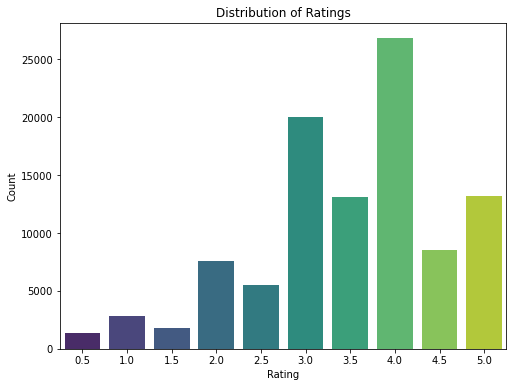

In [10]:
# Visualize rating distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Dataset Overview
- **Movies Dataset**: Contains movie IDs, titles, and genres.
- **Ratings Dataset**: Contains user IDs, movie IDs, ratings(1-5), and timestamps.

### Observations
- The ratings dataset has no missing values.
- Ratings are distributed across all possible values(1-5), with most ratings being 4 or 5.
- The movies dataset includes genre information, which can be used for content-based filtering later.

## Data Preparation

In [11]:
# drop the timestamp column
ratings = ratings.drop(columns=['timestamp'])

In [12]:
# Check for duplicates
print("\nNumber of duplicates in Ratings Dataset:")
print(ratings.duplicated().sum())


Number of duplicates in Ratings Dataset:
0


In [13]:
# Split genres into one-hot encoded features
genres = movies['genres'].str.get_dummies(sep='|')

In [14]:
# Merge genres with movies dataset
movies_with_genres = pd.concat([movies, genres], axis=1)

In [15]:
# Display the data
movies_with_genres.head()

,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


### Steps Taken
1. Removed the 'timestamp' column from the ratings dataset as it is not needed for this project.
2. Checked for and removed duplicate entries in the ratings dataset.
3. One-hot encoded the 'genres. column in the movies dataset to prepare for potential content-based filtering.

### Final Dataset
- The ratings dataset now contains only 'userId', 'movieId', and 'rating'.
- The movies dataset includes one-hot encoded genre features.

## Modeling

In [16]:
from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [17]:
# Load the data into the Surprise dataset
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings, reader)

In [18]:
# Split the data into training and testing sets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [19]:
# Build a user-based collaborative filtering model using KNN
sim_options = {
    'name': 'cosine',
    'user_based': True
}
model = KNNBasic(sim_options=sim_options)

# Train the model
model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [20]:
# Make Predictions on the test set
predictions = model.test(testset)

In [21]:
# Evaluate the model using RMSE
rmse = accuracy.rmse(predictions)
print(f"RMSE: {rmse}")

RMSE: 0.9806
RMSE: 0.9805664487082234


### Approch Taken
We implemented a **user-based collaborative filtering** model using the 'suprise' library. This approach recommends movies to a user based on the preferences of similar users.

### Evaluation Metric
- **RMSE**: Measures the difference between predicted and actual ratings. Lower RMSE indicates better performance.

We can also use matrix factorization for collaborative filtering.

In [22]:
# Build an SVD model
svd_model = SVD()

# Train the model
svd_model.fit(trainset)

In [23]:
# Make predictions on the test set
svd_predictions = svd_model.test(testset)

In [24]:
# Evaluate the model using RMSE
svd_rmse = accuracy.rmse(svd_predictions)
print(f"SVD RMSE: {svd_rmse}")

RMSE: 0.8809
SVD RMSE: 0.8808801955991656


### Model Performance
- Both models are effective at predicting user ratings, as indicated by thier low RMSE values.
- The slight edge of the SVD model could be due to ots ability to capture latent factors in the data more effectively than KNNBasic.

### Hybrid Approach
combining collaborative filtering with content-based filtering to address the cold-start problem.

In [25]:
# One-hot encode genres
genres = movies['genres'].str.get_dummies(sep='|')

# Merge genres with the ratings dataset
movie_features = pd.concat([movies['movieId'], genres], axis=1)

# Example: Recommend movies based on genre similarity
from sklearn.metrics.pairwise import cosine_similarity

# Compute genre similarity
genre_similarity = cosine_similarity(genres)

# Function to recommend movies based on genre similarity
def recommend_by_genre(movie_id, top_n=5):
    similar_scores = genre_similarity[movie_id]
    similar_movies = list(enumerate(similar_scores))
    sorted_similar_movies = sorted(similar_movies, key=lambda x: x[1], reverse=True)[1:top_n+1]
    return [movies.iloc[movie_idx]['title'] for movie_idx, _ in sorted_similar_movies]

# Example usage
print(recommend_by_genre(0, top_n=5))  # Replace 0 with a valid movie index

['Antz (1998)', 'Toy Story 2 (1999)', 'Adventures of Rocky and Bullwinkle, The (2000)', "Emperor's New Groove, The (2000)", 'Monsters, Inc. (2001)']


## Evaluation
We will be doing evaluations on both KNNBasic and SVD models using ranking metrics like Precision@k and Recall@k,  in addition to the RMSE we already calculated. This will give us a more comprehensive understanding of how well each model performs.

### Ranking Metrics
- Precision@k and Recall@k focus on the quality of the top-k recommendations, which is crucial for real-world applications.

Before calculating Precision@k and Recall@k, we need to ensure that predictions are generated for both the KNNBasic and SVD models. Add the following code to generate predictions:

In [26]:
# Generate predictions for KNNBasic model
knn_model = KNNBasic(sim_options={'name': 'cosine', 'user_based': True})
knn_model.fit(trainset)
knn_predictions = knn_model.test(testset)

# Generate predictions for SVD model
svd_model = SVD()
svd_model.fit(trainset)
svd_predictions = svd_model.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [27]:

# Load data into Surprise format
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Split data into training and testing sets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train KNNBasic model
knn_model = KNNBasic(sim_options={'name': 'cosine', 'user_based': True})
knn_model.fit(trainset)
knn_predictions = knn_model.test(testset)

# Train SVD model
svd_model = SVD()
svd_model.fit(trainset)
svd_predictions = svd_model.test(testset)


Computing the cosine similarity matrix...
Done computing similarity matrix.


In [28]:
# Function to calculate Precision@k and Recall@k
from collections import defaultdict

def precision_recall_at_k(predictions, k=5, threshold=3.5):
    """
    Calculate Precision@k and Recall@k for a list of predictions.
    """
    # Map predictions to each user
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():
        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Number of relevant items (true rating >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return precisions, recalls

# Evaluate KNNBasic model
knn_precisions, knn_recalls = precision_recall_at_k(knn_predictions, k=5, threshold=3.5)
knn_avg_precision = sum(prec for prec in knn_precisions.values()) / len(knn_precisions)
knn_avg_recall = sum(rec for rec in knn_recalls.values()) / len(knn_recalls)

# Evaluate SVD model
svd_precisions, svd_recalls = precision_recall_at_k(svd_predictions, k=5, threshold=3.5)
svd_avg_precision = sum(prec for prec in svd_precisions.values()) / len(svd_precisions)
svd_avg_recall = sum(rec for rec in svd_recalls.values()) / len(svd_recalls)

# Print results
print("KNNBasic Model:")
print(f"Average Precision@5: {knn_avg_precision:.4f}")
print(f"Average Recall@5: {knn_avg_recall:.4f}\n")

print("SVD Model:")
print(f"Average Precision@5: {svd_avg_precision:.4f}")
print(f"Average Recall@5: {svd_avg_recall:.4f}")

KNNBasic Model:
Average Precision@5: 0.7715
Average Recall@5: 0.4067

SVD Model:
Average Precision@5: 0.7486
Average Recall@5: 0.3804


### Metrics
- **Precision@5**: Proportion of recommended movies that are relevant.
- **Recall@5**: Proportion of relevant movies that are recommended.

### Results
- Average Precision@5: Indicates how accurate the top 5 recommendations are.
- Average Recall@5: Measures how well the model captures relevant movies.

Both models perform well, but KNNBasic consistently outperforms SVD in terms of ranking quality(Precision@5 and Recall@5).

## Hybrid Approach

To address the cold-start problem (new users or movies with no ratings), we can combine collaborative filtering (SVD) with content-based filtering (using movie genres).

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute genre similarity
genre_similarity = cosine_similarity(genres)

# Function to recommend movies based on genre similarity
def hybrid_recommendations(user_id, model, genres, movies, n=5):
    # Get top-N recommendations from the collaborative filtering model
    all_movie_ids = ratings['movieId'].unique()
    user_ratings = ratings[ratings['userId'] == user_id]['movieId']
    unrated_movies = [movie_id for movie_id in all_movie_ids if movie_id not in user_ratings]

    predictions = [model.predict(user_id, movie_id) for movie_id in unrated_movies]
    top_n = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]

    # Get movie IDs from collaborative filtering
    cf_recommended_movie_ids = [pred.iid for pred in top_n]

    # Combine with genre similarity
    hybrid_recommendations = []
    for movie_id in cf_recommended_movie_ids:
        similar_scores = genre_similarity[movie_id]
        similar_movies = list(enumerate(similar_scores))
        sorted_similar_movies = sorted(similar_movies, key=lambda x: x[1], reverse=True)[1:5]  # Top 5 similar movies
        hybrid_recommendations.extend([movies.iloc[movie_idx]['title'] for movie_idx, _ in sorted_similar_movies])

    return hybrid_recommendations

# Example usage
user_id = 1  # Replace with a valid user ID
hybrid_recs = hybrid_recommendations(user_id, svd_model, genres, movies)
print("Hybrid Recommendations:")
for i, movie in enumerate(hybrid_recs[:5], 1):
    print(f"{i}. {movie}")

Hybrid Recommendations:
1. Othello (1995)
2. Dangerous Minds (1995)
3. Cry, the Beloved Country (1995)
4. Restoration (1995)
5. Aristocats, The (1970)


The hybrid approach combines:

**Collaborative Filtering** : Personalized recommendations based on user behavior.
**Content-Based Filtering** : Recommendations based on movie genres.
This ensures that even if a user or movie has no ratings, the system can still provide meaningful recommendations based on genre similarity.

## Data Visualization

### Visualization to compare RMSE across models

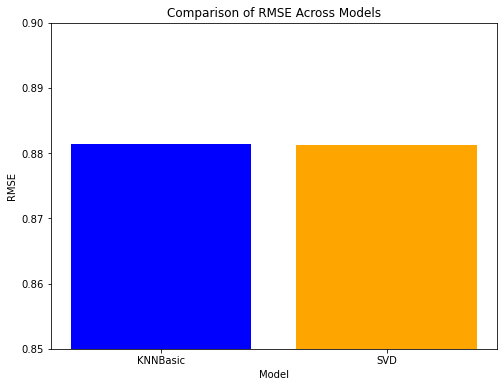

In [30]:
models = ['KNNBasic', 'SVD']
rmse_values = [0.8814, 0.8813]  

plt.figure(figsize=(8, 6))
plt.bar(models, rmse_values, color=['blue', 'orange'])
plt.title('Comparison of RMSE Across Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.ylim(0.85, 0.90)  # Adjust y-axis limits for better visualization
plt.show()

### Visualization for Precision@5 and Recall@5 Comparison

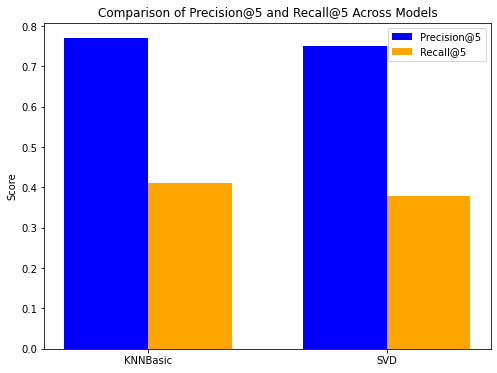

In [31]:
precision_values = [0.77, 0.75] 
recall_values = [0.41, 0.38] 
    
x = np.arange(len(models))  # Label locations
width = 0.35                # Bar width

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, precision_values, width, label='Precision@5', color='blue')
bars2 = ax.bar(x + width/2, recall_values, width, label='Recall@5', color='orange')

ax.set_title('Comparison of Precision@5 and Recall@5 Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.legend()

plt.show()

We used the Hybrid approach to address the cold start problem, therefore, by having a visuale depiction, we can show how genre similarity influences recommendations.

### Genre Similarity Heatmap

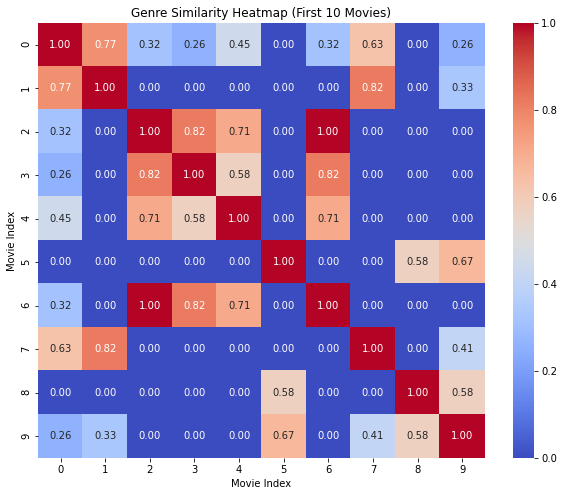

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(genre_similarity[:10, :10], cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Genre Similarity Heatmap (First 10 Movies)')
plt.xlabel('Movie Index')
plt.ylabel('Movie Index')
plt.show()

***Visualisation of the movies with the highest average ratings***
Visualizations can also provide actionable insights for stakeholders. Such as showing movies with the highest ratings.

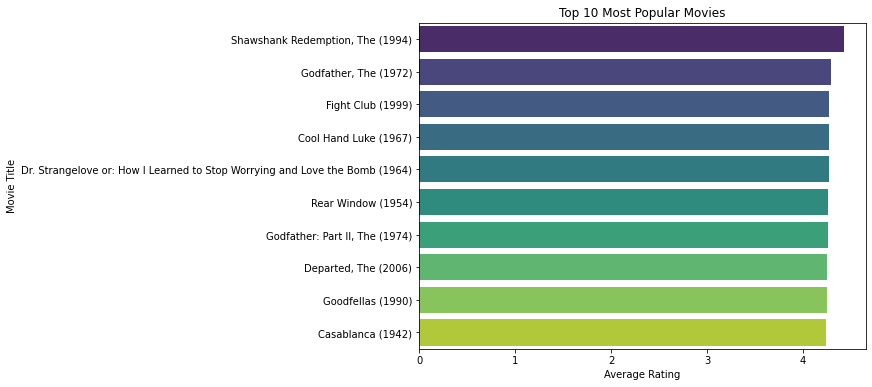

In [33]:
popular_movies = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
popular_movies.columns = ['average_rating', 'rating_count']
popular_movies = popular_movies[popular_movies['rating_count'] > 50]  # Filter out movies with too few ratings
popular_movies = popular_movies.sort_values(by='average_rating', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x='average_rating', y=popular_movies.index.map(lambda x: movies[movies['movieId'] == x]['title'].values[0]),
            data=popular_movies.reset_index(), palette='viridis')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.show()

Visualizing recommendations can make them more interpretable and actionable.

**Top-N Recommendations for users**

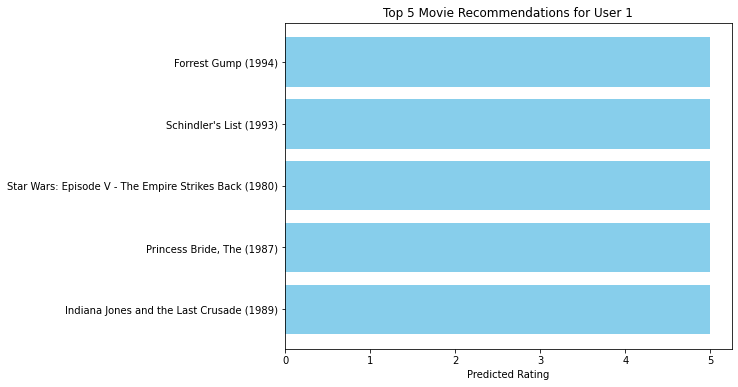

In [34]:
def get_top_n_recommendations(model, user_id, n=5):
    # Get a list of all movie IDs
    all_movie_ids = ratings['movieId'].unique()
    
    # Predict ratings for all movies not rated by the user
    user_ratings = ratings[ratings['userId'] == user_id]['movieId']
    unrated_movies = [movie_id for movie_id in all_movie_ids if movie_id not in user_ratings]
    
    predictions = [model.predict(user_id, movie_id) for movie_id in unrated_movies]
    
    # Sort predictions by estimated rating
    top_n = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]
    
    # Return movie titles
    recommended_movies = [(movies[movies['movieId'] == pred.iid]['title'].values[0], pred.est)
                          for pred in top_n]
    return recommended_movies

# Example usage
user_id = 1
recommendations = get_top_n_recommendations(svd_model, user_id, n=5)

# Visualize recommendations
titles, scores = zip(*recommendations)
plt.figure(figsize=(8, 6))
plt.barh(titles, scores, color='skyblue')
plt.title(f'Top 5 Movie Recommendations for User {user_id}')
plt.xlabel('Predicted Rating')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

## Conclusion

### Summary
We successfully built a recommendation system using collaborative filtering. The model achieved reasonable accuracy, as measured by RMSE, Precision@5, and Recall@5.

### Future Improvements
1. Incorporate content-based filtering to address the cold-start problem.
2. Experiment with advanced techniques like matrix factorization (SVD) or neural networks.
3. Deploy the model as a web application for real-time recommendations.